In [1]:
# top: 2 slides + pie chart showing cells per slide, bottom: UMAP of raw data by a) cell type and b) spatial domain

In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
import sys

sys.path.append('../scripts')

In [4]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split

from utils import set_seed

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
set_seed(0)

# Get dataset

In [6]:
adata = sc.read_h5ad('/data2/a330d/datasets/crc/processed/crc_cosmx_wt.h5ad')

In [7]:
labels_key = 'coarse_type'
domains_key = 'typ'
batch_key = 'sid'

In [8]:
adata = adata[adata.obs[batch_key]!=110].copy()

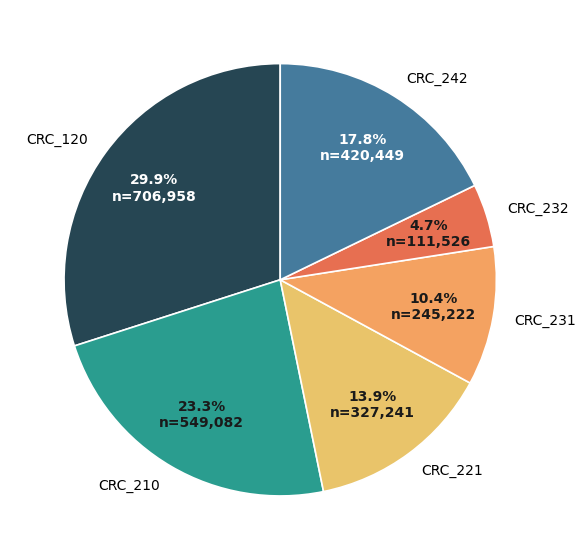

In [ ]:
counts = adata.obs['sid'].value_counts().sort_index()
total  = counts.sum()
labels = [f'CRC_{i}' for i in counts.index.tolist()]
sizes  = counts.values

PALETTE = ['#264653','#2A9D8F','#E9C46A','#F4A261','#E76F51',
           '#457B9D','#A8DADC','#E63946']
colors = PALETTE[:len(labels)]

def autopct(pct):
    n = int(round(pct * total / 100))
    return f'{pct:.1f}%\nn={n:,}'

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct=autopct, startangle=90,
    pctdistance=0.72,
    wedgeprops=dict(linewidth=1.2, edgecolor='white'),
    textprops=dict(fontsize=10),
)
for at, color in zip(autotexts, colors):
    r, g, b = tuple(int(color[i:i+2],16)/255 for i in (1,3,5))
    lum = 0.2126*r + 0.7152*g + 0.0722*b
    at.set_color('white' if lum < 0.45 else '#1a1a1a')
    at.set_fontweight('bold')

patches = [mpatches.Patch(color=c, label=f'{l}  (n={v:,})') 
           for c, l, v in zip(colors, labels, sizes)]
#ax.legend(handles=patches, loc='lower center',
#          bbox_to_anchor=(0.5,-0.12), ncol=3,
#          frameon=False, fontsize=9)
#ax.set_title('Cell counts per slide', fontsize=13, pad=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/crc_piechart.svg', bbox_inches='tight')

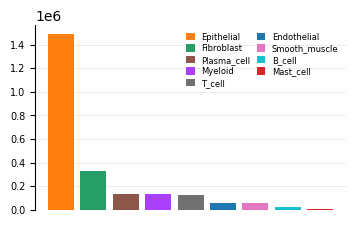

In [42]:
sorted_celltypes = sorted(adata.obs[labels_key].unique())
sorted_celltypes = sorted_celltypes[1:]
sorted_celltypes.append('B_cell')
color_dict = dict(zip(sorted_celltypes, sc.pl.palettes.default_20[:len(sorted_celltypes)]))
color_dict['T_cell'] = "#727171"

counts = adata.obs[labels_key].value_counts().sort_values(ascending=False)
colors = [color_dict[ct] for ct in counts.index]

n = len(counts)
width = 0.6
gap = 0.15
x = np.arange(n) * (width + gap)

fig, ax = plt.subplots(figsize=(3.5, 2.2))
ax.bar(x, counts.values, width=width, color=colors, linewidth=0, zorder=3)

ax.set_xticks([])
ax.set_xlim(-width, x[-1] + width)
#ax.set_ylabel("Cell count", fontsize=7, labelpad=4)
#ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.yaxis.grid(True, linewidth=0.4, color='#dddddd', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(axis='y', labelsize=7)

patches = [mpatches.Patch(facecolor=c, label=l, linewidth=0) for c, l in zip(colors, counts.index)]
ax.legend(handles=patches, frameon=False, fontsize=6, ncol=2,
          loc='upper right', handlelength=1, handleheight=1,
          columnspacing=0.8, labelspacing=0.3)

plt.tight_layout(pad=0.5)
plt.savefig('../figures/crc_celltypes.svg', bbox_inches='tight')
plt.show()

In [12]:
adata_1 = adata[adata.obs[batch_key]==242]
adata_2 = adata[adata.obs[batch_key]==232]

/tmp/ipykernel_1128740/1017688770.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  axs = sc.pl.spatial(adata_1, color=[domains_key, labels_key], spot_size=100, show=False)


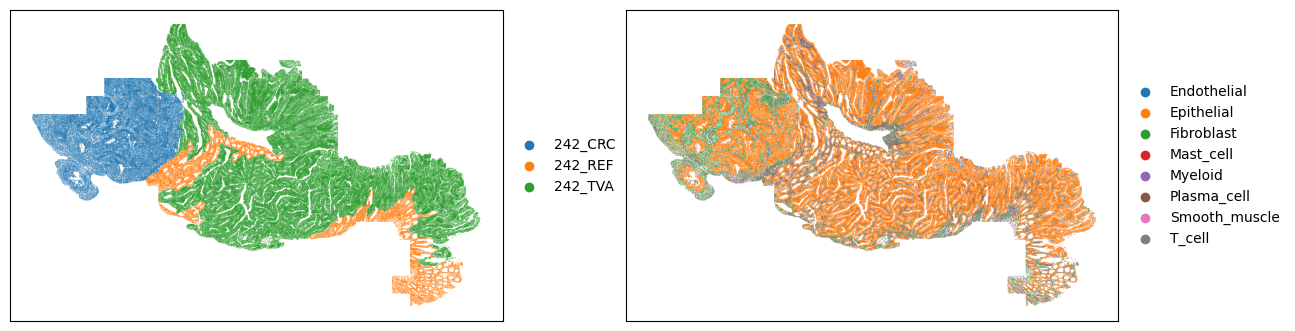

In [14]:
axs = sc.pl.spatial(adata_1, color=[domains_key, labels_key], spot_size=100, show=False)
for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
plt.savefig('../figures/crc_slide_242.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
sc.pp.neighbors(adata_1)
sc.tl.umap(adata_1)

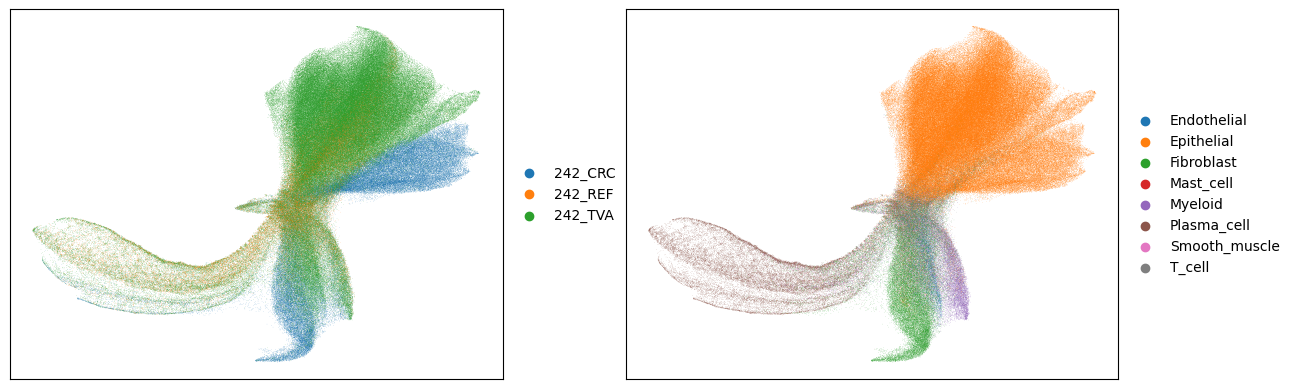

In [18]:
axs = sc.pl.umap(adata_1, color=[domains_key, labels_key], show=False)
for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
plt.savefig('../figures/crc_slide_242_umap.png', dpi=300, bbox_inches='tight')
plt.show()